<a href="https://colab.research.google.com/github/Nailaskn/Analisis-Numerik-NailaSecondaiva/blob/main/ANALISIS_NUMERIK_KAPAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NAMA: NAILA SECONDAIVA ARTA PUTRI
# NPM: 25083010013
# KELAS: A083
# MATA KULIAH: ANALISIS NUMERIK

### Diketahui

- Jarak antar titik pengukuran ($\Delta x$) = 45 cm
- Jumlah titik pengukuran = 17 titik
- Jumlah interval = 16 interval
- Metode integrasi numerik yang digunakan = Simpson 1/3
- Lebar lambung diukur pada setiap titik berdasarkan gambar tampak atas.
- Tinggi lambung diukur berdasarkan gambar tampak samping.
- Volume dihitung tanpa memperhitungkan reserve buoyancy.
- Luas penampang pada setiap titik dihitung dengan:

$$
A_i = w_i \times h_i
$$

dengan:
- $A_i$ = luas penampang pada titik ke-$i$ ($cm^2$)
- $w_i$ = lebar lambung pada titik ke-$i$ (cm)
- $h_i$ = tinggi lambung pada titik ke-$i$ (cm)

Perhitungan volume dilakukan menggunakan metode Simpson 1/3 dengan 16 interval yang berjarak sama.

## 1. Upload Gambar Kapal

In [30]:
!pip -q install pymupdf opencv-python-headless

import fitz
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display

Saving perahu.png to perahu (3).png
Ukuran gambar: (1688, 3000, 3)


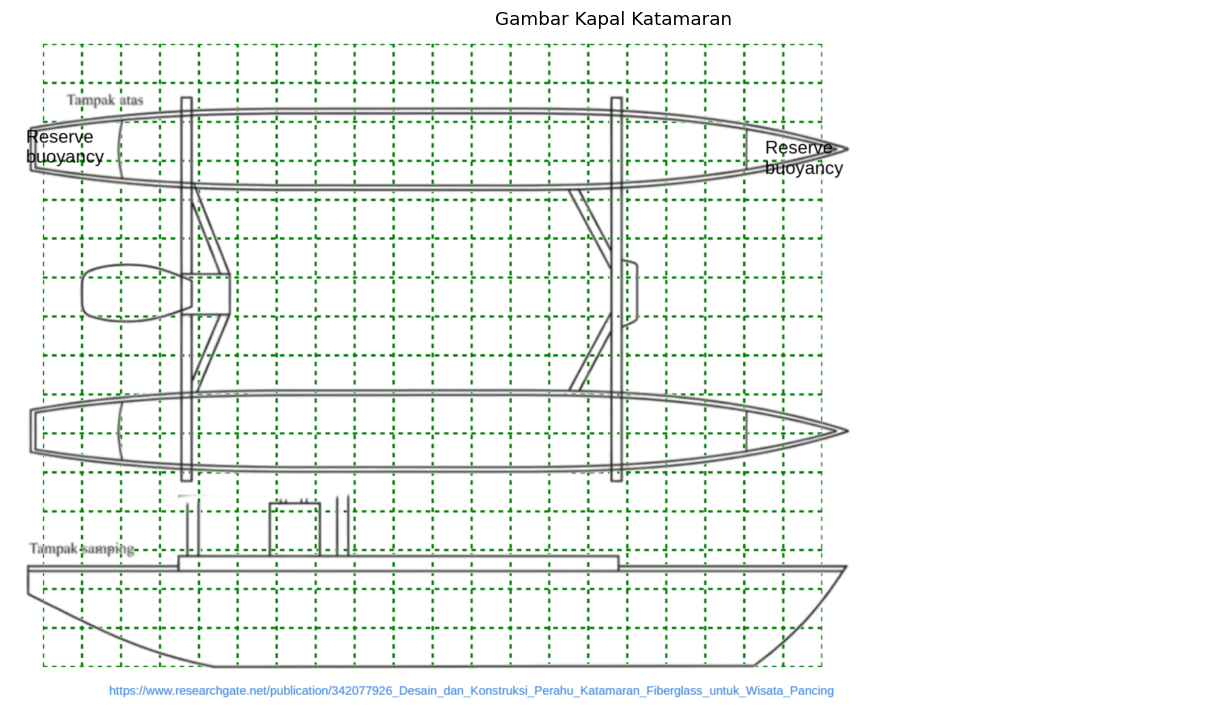

In [31]:
# Upload file PDF
uploaded = files.upload()

pdf_name = list(uploaded.keys())[0]

# Membuka PDF
doc = fitz.open(pdf_name)

# Mengambil halaman pertama yang berisi gambar kapal
page = doc[0]

# Render halaman menjadi gambar
pix = page.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)

img_path = "perahu.png"
pix.save(img_path)

# Membaca gambar
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar:", img_rgb.shape)

plt.figure(figsize=(16, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Gambar Kapal Katamaran")
plt.show()


## 2. Mendeteksi Grid dan Menentukan Skala

In [32]:
# Pisahkan channel warna
b, g, r = cv2.split(img)

# Mask warna hijau untuk mendeteksi grid
green_mask = (
    (g > 100) &
    (g > r * 1.15) &
    (g > b * 1.15)
)

# Hitung jumlah pixel hijau pada setiap kolom
column_count = green_mask.sum(axis=0)

# Cari kolom yang merupakan garis vertikal grid
candidate_x = np.where(column_count > 300)[0]

# Kelompokkan pixel yang berdekatan
groups = []

for x in candidate_x:
    if not groups or x > groups[-1][-1] + 1:
        groups.append([x])
    else:
        groups[-1].append(x)

# Posisi tengah setiap garis grid
grid_x = np.array([int(np.mean(group)) for group in groups])

print("Jumlah garis grid vertikal :", len(grid_x))
print("Jumlah interval keseluruhan:", len(grid_x) - 1)
print("Posisi garis grid:", grid_x)

Jumlah garis grid vertikal : 21
Jumlah interval keseluruhan: 20
Posisi garis grid: [  80  176  273  370  468  564  661  758  855  952 1049 1146 1243 1339
 1437 1534 1631 1728 1825 1922 2018]


In [33]:
# Total grid = 20 interval
# Reserve buoyancy kiri dan kanan tidak dihitung.
# Digunakan grid ke-2 sampai grid ke-18.

start_grid = 2
end_grid = 18

# 17 titik untuk 16 interval
station_x = grid_x[start_grid:end_grid + 1]

print("Jumlah titik:", len(station_x))
print("Jumlah interval:", len(station_x) - 1)

# Skala
grid_spacing_px = np.mean(np.diff(grid_x))

grid_cm = 45
grid_m = 0.45

cm_per_pixel = grid_cm / grid_spacing_px
m_per_pixel = grid_m / grid_spacing_px

panjang_m = (len(station_x) - 1) * grid_m

print(f"Jarak rata-rata antar-grid : {grid_spacing_px:.2f} pixel")
print(f"Skala                     : {grid_cm} cm/grid")
print(f"Skala                     : {m_per_pixel:.6f} m/pixel")
print(f"Panjang analisis          : {panjang_m:.2f} m")

Jumlah titik: 17
Jumlah interval: 16
Jarak rata-rata antar-grid : 96.90 pixel
Skala                     : 45 cm/grid
Skala                     : 0.004644 m/pixel
Panjang analisis          : 7.20 m


Hasil deteksi menunjukkan terdapat 21 garis grid sehingga terdapat 20 interval pada gambar.

Setelah bagian reserve buoyancy di kedua ujung dikeluarkan, titik perhitungan dimulai dari grid ke-2 sampai grid ke-18. Dengan demikian diperoleh:

- 17 titik
- 16 interval
- panjang setiap interval = 0,45 m
- panjang bagian kapal yang dihitung = 7,20 m

Jadi, perhitungan numerik tidak menggunakan area reserve buoyancy.

## 3. Menentukan Titik Perhitungan

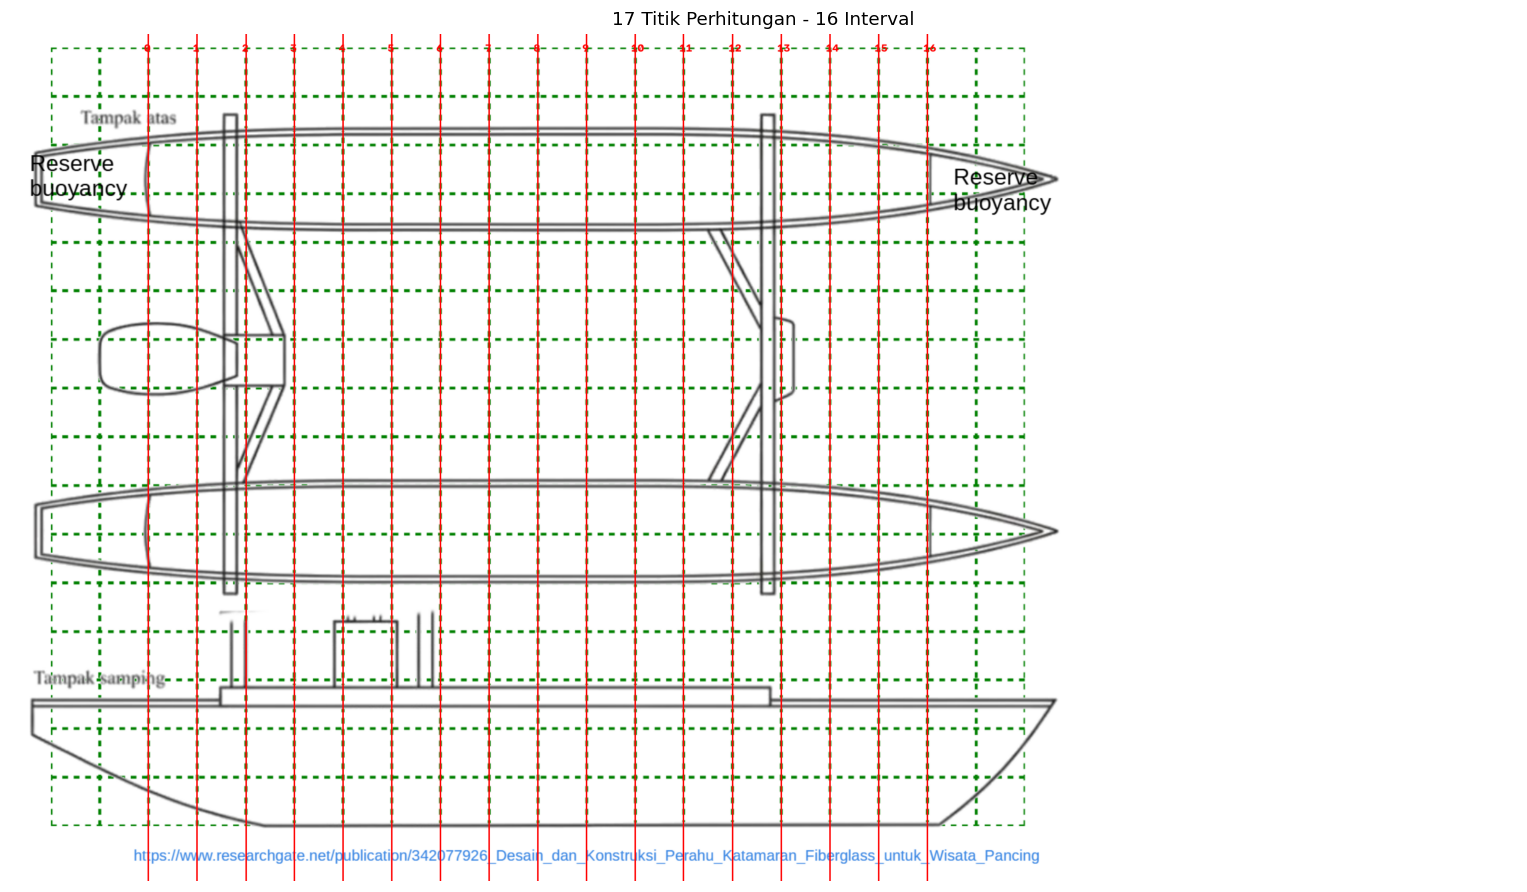

In [34]:
# Tampilkan garis stasiun pada gambar
gambar_stasiun = img_rgb.copy()

for i, x in enumerate(station_x):
    cv2.line(
        gambar_stasiun,
        (int(x), 0),
        (int(x), gambar_stasiun.shape[0]),
        (255, 0, 0),
        2
    )

    cv2.putText(
        gambar_stasiun,
        f"{i}",
        (int(x) - 8, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(18, 10))
plt.imshow(gambar_stasiun)
plt.axis("off")
plt.title("17 Titik Perhitungan - 16 Interval")
plt.show()

Gambar menunjukkan 17 garis yang digunakan dalam perhitungan numerik.

Jarak antara dua titik berurutan adalah satu grid, yaitu:

$$
\Delta x = 0,45\text{ m}
$$

Dengan 17 titik, terdapat 16 interval:

$$
0,45 + 0,45 + \cdots + 0,45
= 16(0,45)
= 7,20\text{ m}
$$

Garis di luar batas tersebut tidak digunakan karena termasuk bagian reserve buoyancy.

## 4. Menentukan Lebar Lambung pada Setiap Titik

In [36]:
# Citra grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Mask garis abu-abu/hitam.
# Warna hijau grid disaring dengan syarat RGB relatif sama.
neutral_mask = (
    (np.max(img, axis=2).astype(float) - np.min(img, axis=2).astype(float) < 15) &
    (gray < 200)
)

def get_runs(values):
    runs = []
    for y in values:
        y = int(y)
        if not runs or y > runs[-1][-1] + 1:
            runs.append([y])
        else:
            runs[-1].append(y)
    return [(r[0], r[-1]) for r in runs]

def detect_groups(x, y0, y1, threshold=3):
    area = neutral_mask[y0:y1, max(0, x-15):min(img.shape[1], x+16)]
    values = np.where(area.sum(axis=1) > threshold)[0] + y0
    return get_runs(values)

# Menentukan batas y secara dinamis berdasarkan proporsi gambar
height = img.shape[0]
y_start = int(height * 0.05)
y_end = int(height * 0.55)

width_pixel = []

for x in station_x:
    groups = detect_groups(x, y_start, y_end)

    # Jika terdeteksi minimal dua kelompok garis lambung
    if len(groups) >= 2:
        # Kelompok pertama adalah bagian atas lambung, kelompok terakhir adalah bagian bawah lambung
        top = groups[0]
        bottom = groups[-1]

        top_center = (top[0] + top[1]) / 2
        bottom_center = (bottom[0] + bottom[1]) / 2
        width_pixel.append(bottom_center - top_center)
    else:
        # Berikan nilai fallback jika deteksi gagal di titik tertentu
        width_pixel.append(0.0)

width_pixel = np.array(width_pixel)

# Konversi pixel menjadi meter
width_meter = width_pixel * m_per_pixel

print("Lebar lambung tiap titik:")
for i, w in enumerate(width_meter):
    print(f"Titik {i:2d} : {w:.4f} m")

Lebar lambung tiap titik:
Titik  0 : 3.4899 m
Titik  1 : 3.3065 m
Titik  2 : 3.3135 m
Titik  3 : 3.3111 m
Titik  4 : 3.3158 m
Titik  5 : 3.3135 m
Titik  6 : 3.3135 m
Titik  7 : 3.3135 m
Titik  8 : 3.3135 m
Titik  9 : 3.3135 m
Titik 10 : 3.3135 m
Titik 11 : 3.3158 m
Titik 12 : 3.3158 m
Titik 13 : 0.0000 m
Titik 14 : 3.3158 m
Titik 15 : 3.3065 m
Titik 16 : 2.9559 m


Lebar lambung diperoleh dari tampak atas kapal.

Karena kedua lambung kapal digunakan dalam perhitungan dan bentuk lambung pada gambar dibuat simetris, lebar satu lambung digunakan untuk menentukan luas penampang masing-masing lambung.

Jarak pixel hasil deteksi kemudian dikonversi menjadi meter menggunakan skala:

$$
1\text{ grid}=0,45\text{ m}
$$

## 5. Menentukan Tinggi Lambung pada Setiap Titik

In [38]:
height_pixel = []

# Menentukan batas y dinamis untuk area tampak samping kapal di bagian bawah gambar
height_total = img.shape[0]
y_side_start = int(height_total * 0.70)
y_side_end = int(height_total * 0.98)

for x in station_x:
    # Deteksi kelompok garis pada daerah tampak samping
    groups = detect_groups(x, y_side_start, y_side_end, threshold=3)

    # Jika terdeteksi minimal dua kelompok garis (lantai dek atas dan dasar lambung)
    if len(groups) >= 2:
        top = groups[0]
        bottom = groups[-1]

        top_center = (top[0] + top[1]) / 2
        bottom_center = (bottom[0] + bottom[1]) / 2

        height_pixel.append(bottom_center - top_center)
    else:
        # Nilai fallback jika garis tidak terdeteksi sempurna di stasiun tersebut
        height_pixel.append(0.0)

height_pixel = np.array(height_pixel)

# Konversi pixel ke meter
height_meter = height_pixel * m_per_pixel

print("Tinggi lambung tiap titik:")
for i, h in enumerate(height_meter):
    print(f"Titik {i:2d} : {h:.4f} m")

Tinggi lambung tiap titik:
Titik  0 : 1.1029 m
Titik  1 : 1.0031 m
Titik  2 : 1.5163 m
Titik  3 : 1.2817 m
Titik  4 : 1.2817 m
Titik  5 : 1.5534 m
Titik  6 : 1.2841 m
Titik  7 : 1.2817 m
Titik  8 : 1.2771 m
Titik  9 : 1.2771 m
Titik 10 : 1.2771 m
Titik 11 : 1.2748 m
Titik 12 : 1.2724 m
Titik 13 : 1.1517 m
Titik 14 : 1.1517 m
Titik 15 : 1.1494 m
Titik 16 : 1.1494 m


Tinggi lambung diperoleh dari tampak samping.

Sesuai asumsi pada soal, lantai kapal dianggap datar sehingga penampang depan dapat diperlakukan sebagai persegi panjang.

Dengan demikian, pada setiap titik:

$$
A_i = b_i \times h_i
$$

dengan:
- $(b_i)$ = lebar lambung pada titik ke-$(i)$
- $(h_i)$ = tinggi lambung pada titik ke-$(i)$
- $(A_i)$ = luas penampang pada titik ke-$(i)$

## 6. Menghitung Luas Penampang

Karena tampak depan dianggap berbentuk persegi panjang, luas penampang setiap titik dihitung dengan:

$$
A_i=b_i h_i
$$

Nilai luas penampang ini selanjutnya digunakan sebagai data fungsi untuk integrasi numerik.

In [39]:
# Luas penampang
area_meter = width_meter * height_meter

# Posisi setiap titik
x_meter = np.arange(len(station_x)) * grid_m

# Tabel hasil
data = pd.DataFrame({
    "Titik": np.arange(17),
    "x (m)": x_meter,
    "Lebar (m)": width_meter,
    "Tinggi (m)": height_meter,
    "Luas Penampang (m²)": area_meter
})

display(data.round(4))

,Titik,x (m),Lebar (m),Tinggi (m),Luas Penampang (m²)
0,0,0.00,3.4899,1.1029,3.8492
1,1,0.45,3.3065,1.0031,3.3167
2,2,0.90,3.3135,1.5163,5.0241
3,3,1.35,3.3111,1.2817,4.2440
4,4,1.80,3.3158,1.2817,4.2500
5,5,2.25,3.3135,1.5534,5.1472
6,6,2.70,3.3135,1.2841,4.2547
7,7,3.15,3.3135,1.2817,4.2470
8,8,3.60,3.3135,1.2771,4.2316
9,9,4.05,3.3135,1.2771,4.2316


Tabel menunjukkan dimensi penampang pada 17 titik.

Lebar dan tinggi berubah mengikuti bentuk lambung kapal. Pada bagian tengah kapal, dimensi penampang relatif lebih besar, sedangkan mendekati ujung kapal dimensinya mengecil.

Hal tersebut menyebabkan luas penampang juga tidak konstan sepanjang kapal. Oleh karena itu, volume tidak dihitung menggunakan rumus balok sederhana, tetapi menggunakan integrasi numerik.

## 7. Menghitung Volume dengan Metode Simpson 1/3

Karena terdapat 16 interval, metode Simpson 1/3 dapat digunakan.

Rumus Simpson 1/3:

$$
V=\frac{\Delta x}{3}
\left[
A_0+A_{16}
+4(A_1+A_3+\cdots+A_{15})
+2(A_2+A_4+\cdots+A_{14})
\right]
$$

dengan:

$$
\Delta x=0,45\text{ m}
$$

Perhitungan pertama dilakukan untuk satu lambung. Setelah itu hasilnya dikalikan dua untuk memperoleh volume kedua lambung.

In [40]:
dx = 0.45

# Koefisien Simpson
koefisien = np.array([
    1 if i == 0 or i == 16
    else 4 if i % 2 == 1
    else 2
    for i in range(17)
])

data["Koefisien Simpson"] = koefisien

# Tabel lengkap
display(data.round(4))

# Perhitungan Simpson
jumlah_simpson = np.sum(koefisien * area_meter)

volume_satu_lambung = (dx / 3) * jumlah_simpson

# Karena ada dua lambung
volume_kedua_lambung = 2 * volume_satu_lambung

print("Jumlah Simpson =", jumlah_simpson)
print(f"Volume satu lambung = {volume_satu_lambung:.4f} m³")
print(f"Volume kedua lambung = {volume_kedua_lambung:.4f} m³")

,Titik,x (m),Lebar (m),Tinggi (m),Luas Penampang (m²),Koefisien Simpson
0,0,0.00,3.4899,1.1029,3.8492,1
1,1,0.45,3.3065,1.0031,3.3167,4
2,2,0.90,3.3135,1.5163,5.0241,2
3,3,1.35,3.3111,1.2817,4.2440,4
4,4,1.80,3.3158,1.2817,4.2500,2
5,5,2.25,3.3135,1.5534,5.1472,4
6,6,2.70,3.3135,1.2841,4.2547,2
7,7,3.15,3.3135,1.2817,4.2470,4
8,8,3.60,3.3135,1.2771,4.2316,2
9,9,4.05,3.3135,1.2771,4.2316,4


Jumlah Simpson = 184.16142922869003
Volume satu lambung = 27.6242 m³
Volume kedua lambung = 55.2484 m³


## 8. Hasil Akhir Perhitungan

Volume satu lambung diperoleh menggunakan metode Simpson 1/3.

Karena kapal memiliki dua lambung yang dihitung, volume total diperoleh dengan:

$$
V_{total} = 2V_{lambung}
$$

Area reserve buoyancy tidak dimasukkan dalam perhitungan.

In [41]:
print("=" * 50)
print("HASIL AKHIR ANALISIS NUMERIK")
print("=" * 50)

print(f"Jumlah interval       : {len(station_x)-1}")
print(f"Jumlah titik          : {len(station_x)}")
print(f"Interval Δx           : {dx:.2f} m")
print(f"Panjang analisis      : {(len(station_x)-1)*dx:.2f} m")
print(f"Volume satu lambung   : {volume_satu_lambung:.4f} m³")
print(f"Volume kedua lambung  : {volume_kedua_lambung:.4f} m³")
print("=" * 50)

HASIL AKHIR ANALISIS NUMERIK
Jumlah interval       : 16
Jumlah titik          : 17
Interval Δx           : 0.45 m
Panjang analisis      : 7.20 m
Volume satu lambung   : 27.6242 m³
Volume kedua lambung  : 55.2484 m³


## Kesimpulan

Berdasarkan analisis numerik pada gambar kapal katamaran, perhitungan dilakukan pada 16 interval dengan 17 titik. Satu interval memiliki panjang 0,45 m sehingga panjang bagian kapal yang dianalisis adalah 7,20 m.

Area reserve buoyancy pada kedua ujung kapal tidak dimasukkan ke dalam perhitungan. Pada setiap titik, luas penampang diperoleh dengan mengalikan lebar dan tinggi lambung karena penampang depan diasumsikan berbentuk persegi panjang.

Selanjutnya, volume satu lambung dihitung menggunakan metode Simpson 1/3. Hasil volume kedua lambung diperoleh dengan mengalikan volume satu lambung dengan dua.

Dari hasil ekstraksi gambar dan perhitungan numerik diperoleh volume total kedua lambung sekitar 55.25 m³.